In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
data=pd.read_csv(r"D:\college\course projects\eda cp\data_ecommerce_customer_churn.csv")
data.count()

Tenure                      3747
WarehouseToHome             3772
NumberOfDeviceRegistered    3941
PreferedOrderCat            3941
SatisfactionScore           3941
MaritalStatus               3941
NumberOfAddress             3941
Complain                    3941
DaySinceLastOrder           3728
CashbackAmount              3941
Churn                       3941
dtype: int64

In [35]:
df=pd.DataFrame(data)
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [36]:
df.describe()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3747.000000,3772.000000,3941.000000,3941.000000,3941.000000,3941.000000,3728.000000,3941.000000,3941.000000
mean,10.081398,15.650583,3.679269,3.088302,4.237757,0.282416,4.531652,176.707419,0.171023
std,8.498864,8.452301,1.013938,1.381832,2.626699,0.450232,3.667648,48.791784,0.376576
min,0.000000,5.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,9.000000,3.000000,2.000000,2.000000,0.000000,2.000000,145.700000,0.000000
50%,9.000000,14.000000,4.000000,3.000000,3.000000,0.000000,3.000000,163.340000,0.000000
75%,16.000000,21.000000,4.000000,4.000000,6.000000,1.000000,7.000000,195.250000,0.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,1.000000,46.000000,324.990000,1.000000


In [37]:
#preprocessing

In [38]:
#median for numerical data
df['Tenure'].fillna(df['Tenure'].median(), inplace=True)
df['WarehouseToHome'].fillna(df['WarehouseToHome'].median(),inplace=True)
df['DaySinceLastOrder'].fillna(df['DaySinceLastOrder'].median(), inplace=True)
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,3.0,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [39]:
#dropping null values
df.dropna()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,3.0,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
...,...,...,...,...,...,...,...,...,...,...,...
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3938,30.0,6.0,5,Laptop & Accessory,3,Married,3,1,2.0,156.60,0
3939,6.0,14.0,4,Mobile,3,Married,10,1,0.0,124.37,1


In [40]:
#visualisation

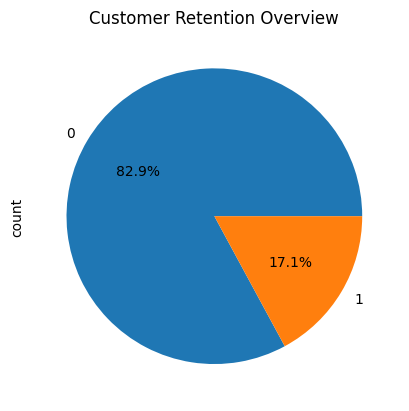

In [41]:
df['Churn'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title("Customer Retention Overview")
plt.show()
#Overview purposes

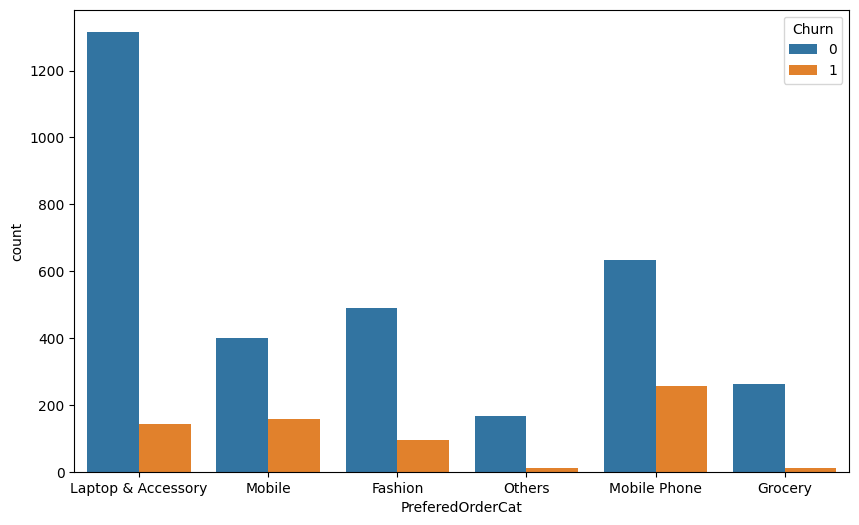

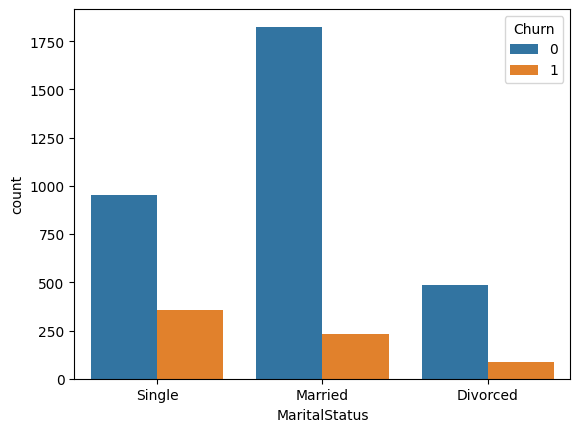

In [42]:
plt.figure(figsize=(10,6))
sns.countplot(x='PreferedOrderCat',hue='Churn',data=df)
plt.show()
sns.countplot(x='MaritalStatus',hue='Churn',data=df)
plt.show()

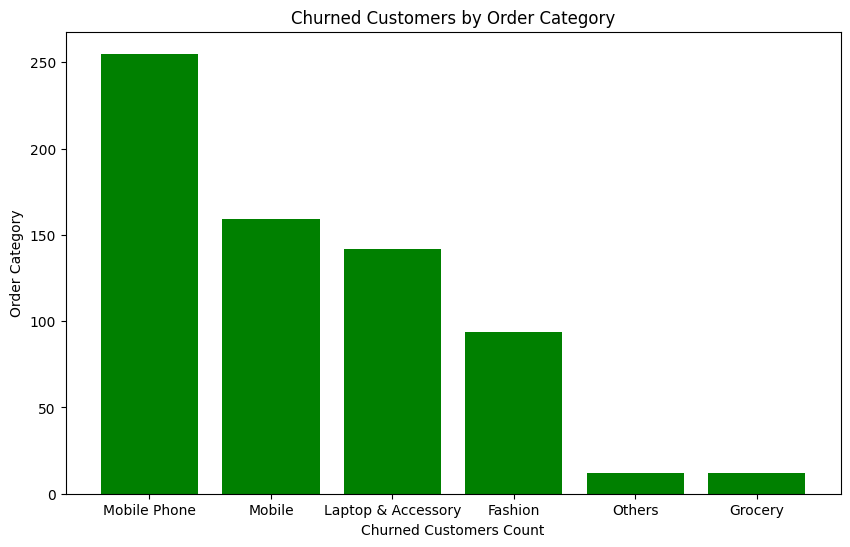

In [43]:
df=pd.DataFrame(data)
churncat=df[df['Churn']==1]['PreferedOrderCat'].value_counts()
plt.figure(figsize=(10,6))
plt.bar(churncat.index,churncat.values,color='green')
plt.xlabel("Churned Customers Count")
plt.ylabel("Order Category")
plt.title("Churned Customers by Order Category")
plt.show()
#To focus on a particular category

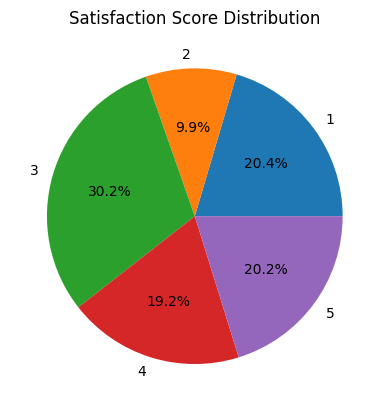

In [44]:
plt.figure()
score = df['SatisfactionScore'].value_counts().sort_index()
plt.pie(score.values,labels=score.index,autopct='%1.1f%%')
plt.title("Satisfaction Score Distribution")
plt.show()
#To understand user experience

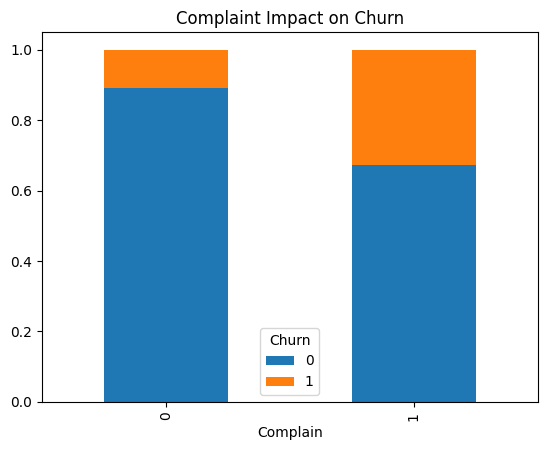

In [45]:
pd.crosstab(df['Complain'], df['Churn'], normalize='index').plot(kind='bar',stacked=True)
plt.title("Complaint Impact on Churn")
plt.show()
#tro understand correlation between user experience and customer support system

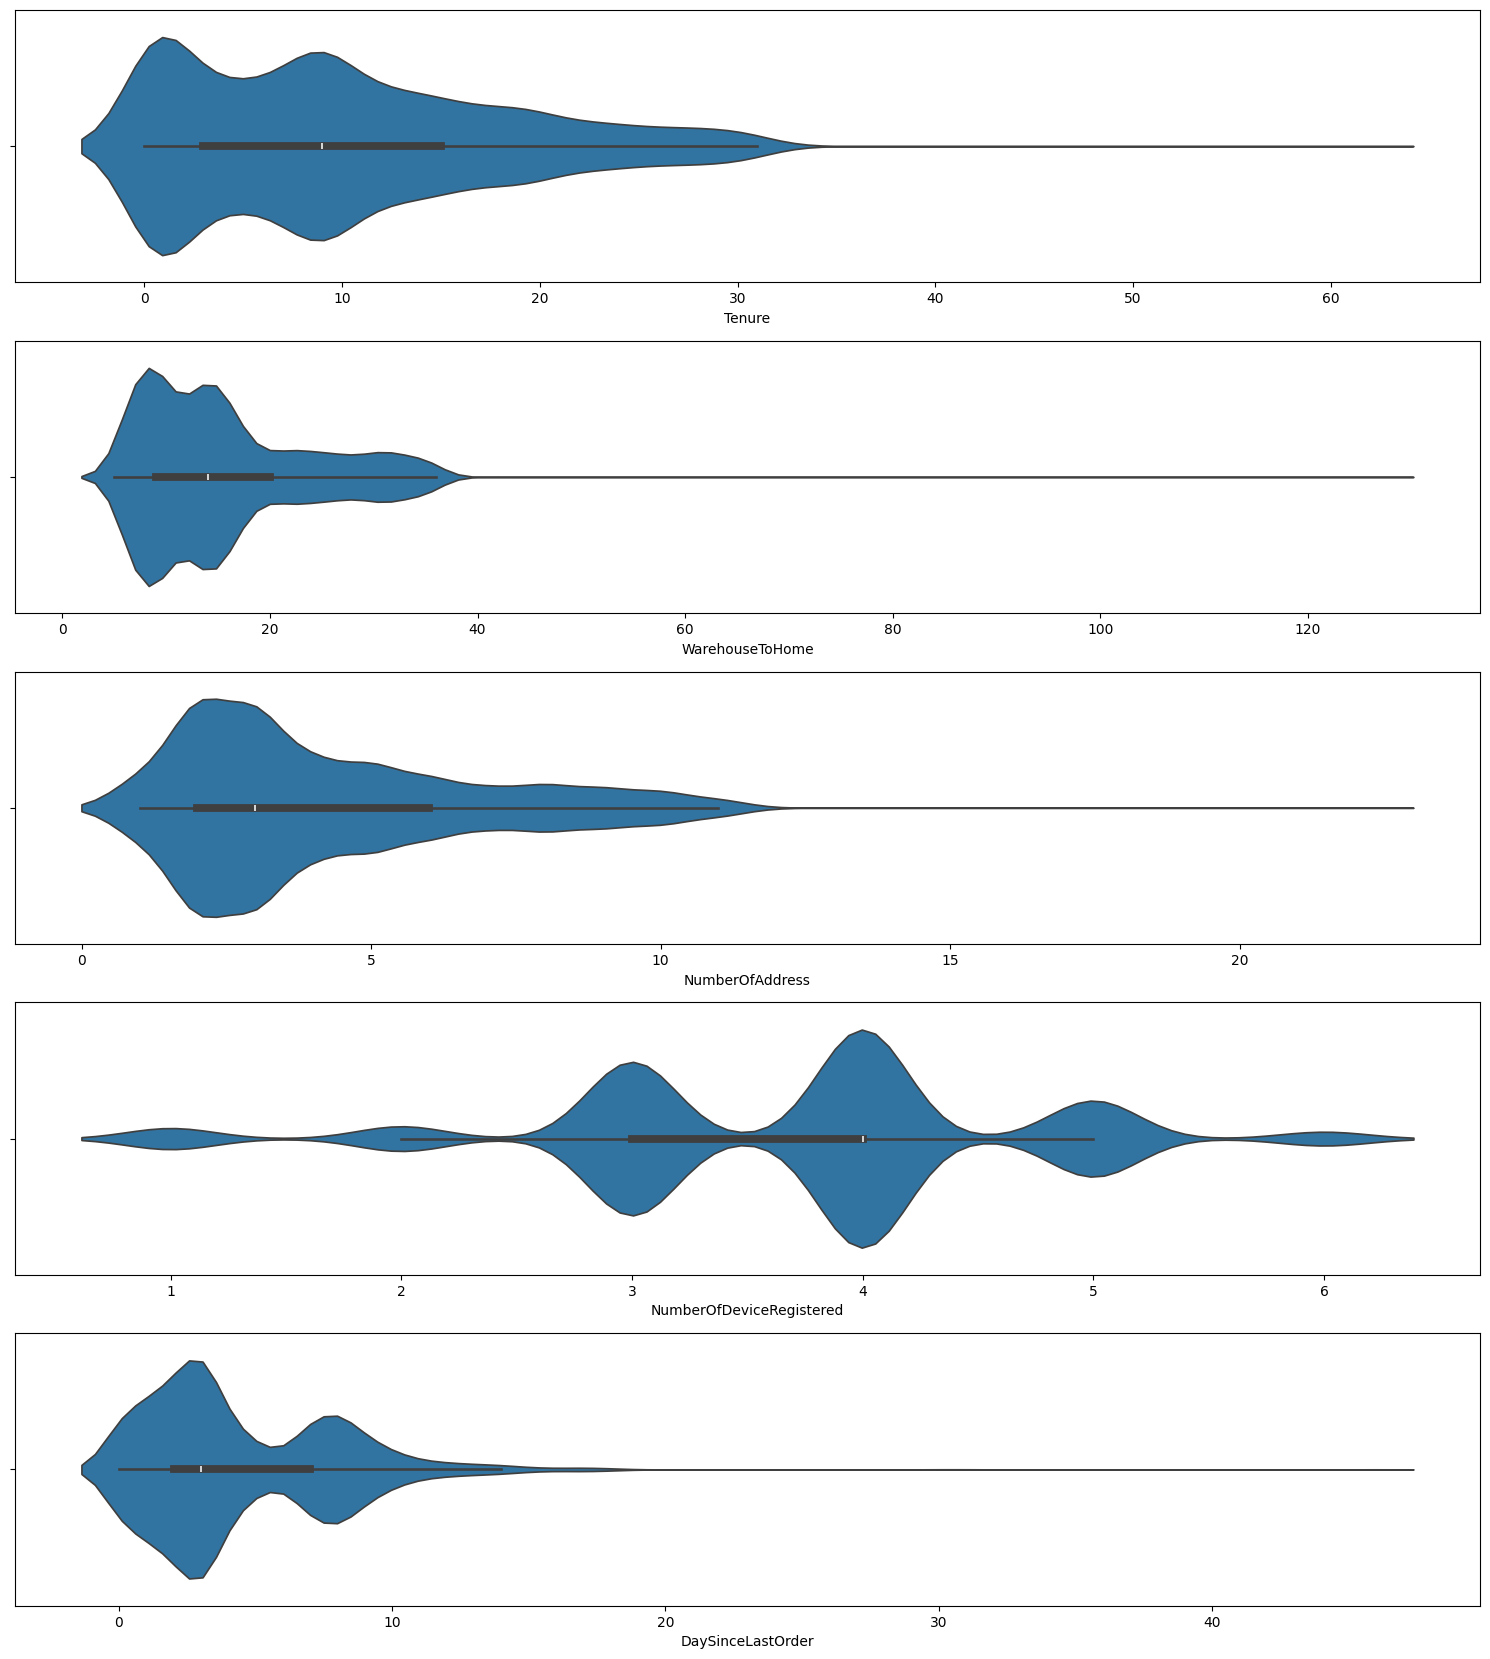

In [46]:
#distribution of data amongst numerical variables
#identification of outliers
num_vars = ['Tenure', 'WarehouseToHome', 'NumberOfAddress', 'NumberOfDeviceRegistered',
            'DaySinceLastOrder', 'CashbackAmount']

fig, axs = plt.subplots(nrows=6, ncols=1, figsize=(15, 20))
axs = axs.flatten()

for i, var in enumerate(num_vars):
    sns.violinplot(x=var, data=df, ax=axs[i])

fig.tight_layout()
fig.delaxes(axs[5])

plt.show()

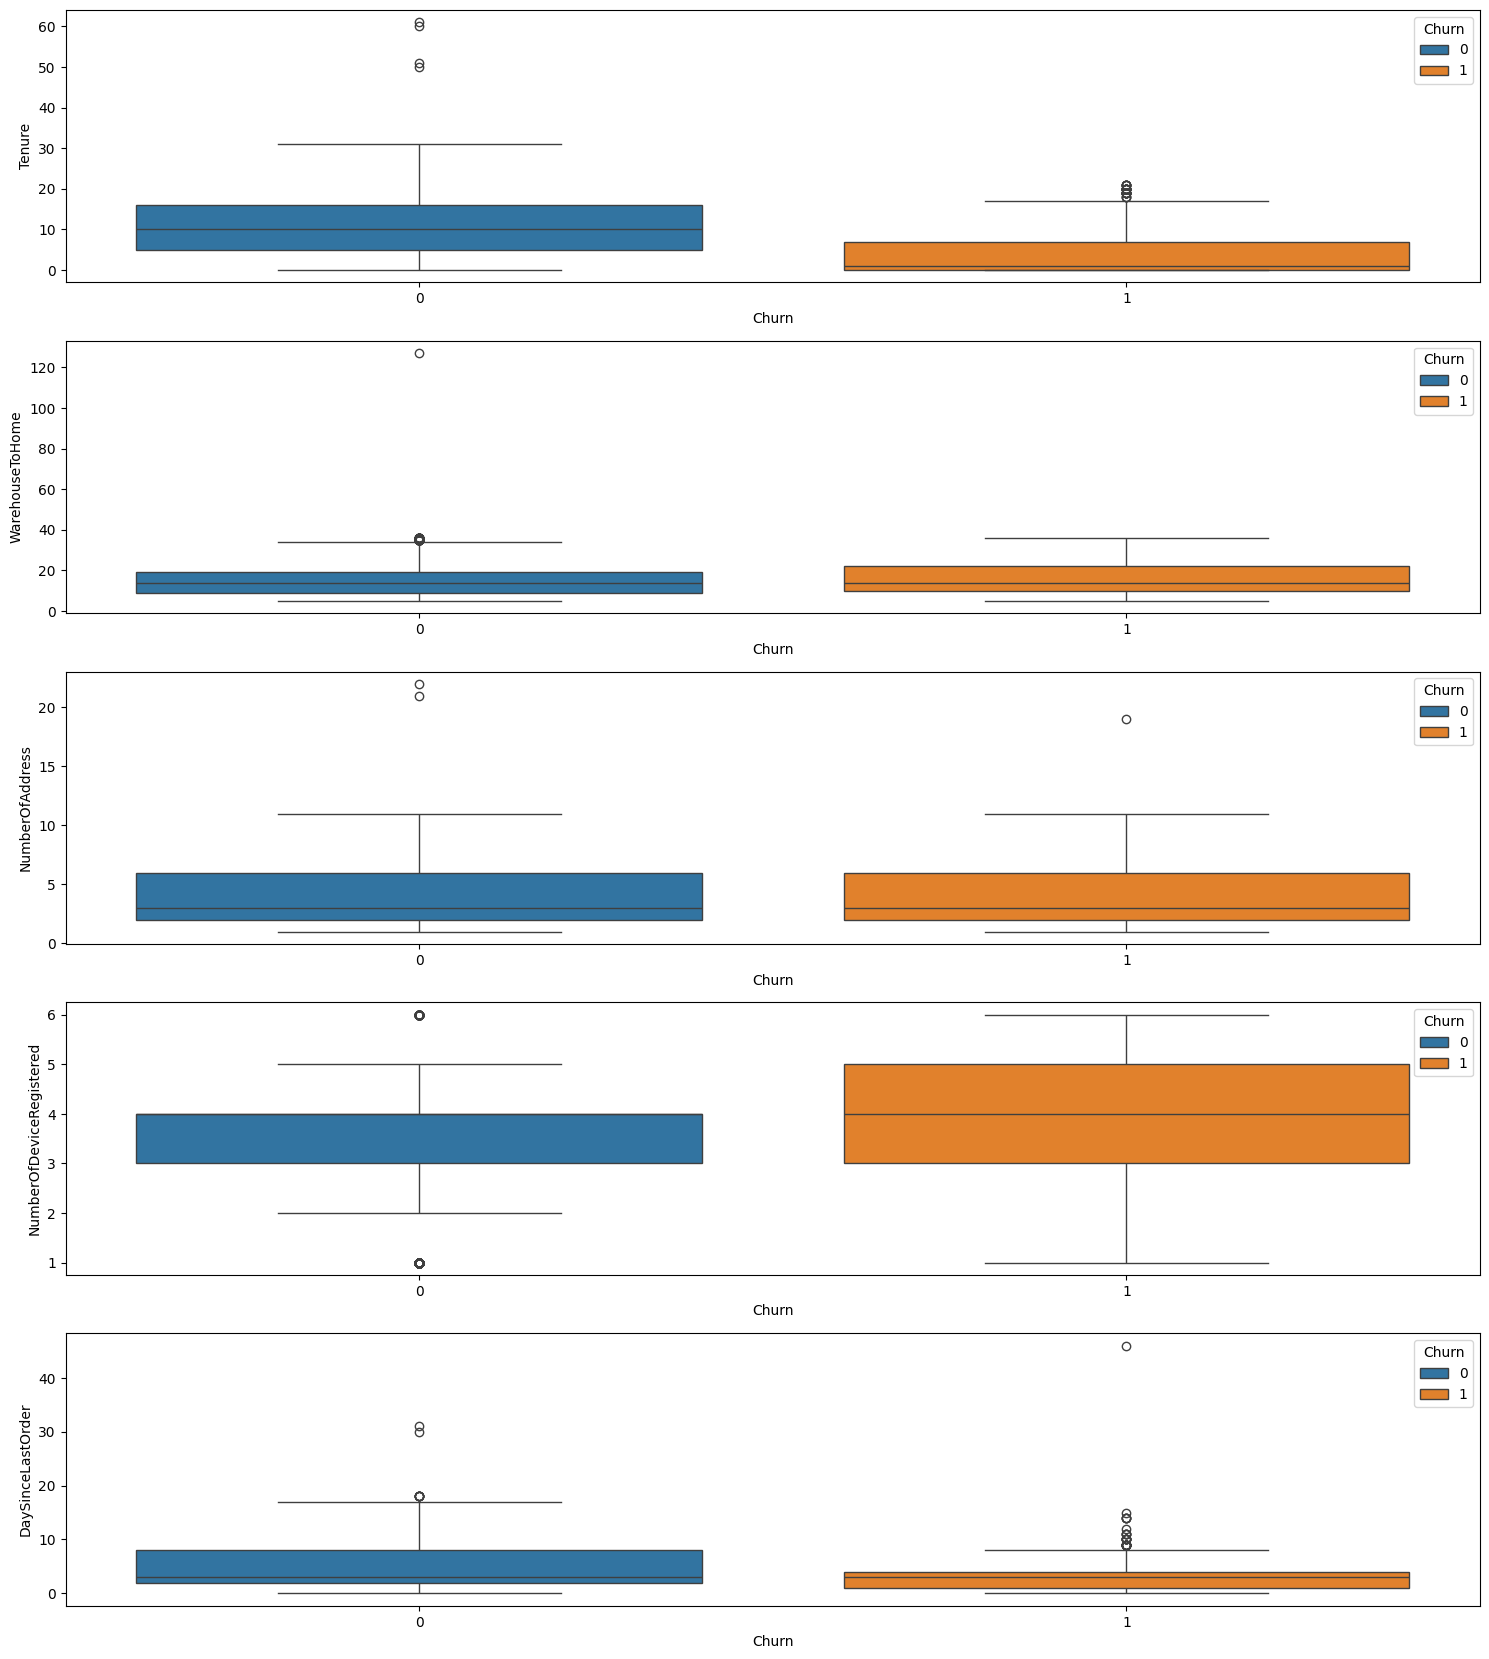

In [47]:
#previous data separated by churn
fig, axs = plt.subplots(nrows=6, ncols=1, figsize=(15, 20))
axs = axs.flatten()

for i, var in enumerate(num_vars):
    sns.boxplot(y=var,x='Churn', hue='Churn',data=df, ax=axs[i])

fig.tight_layout()
fig.delaxes(axs[5])

plt.show()

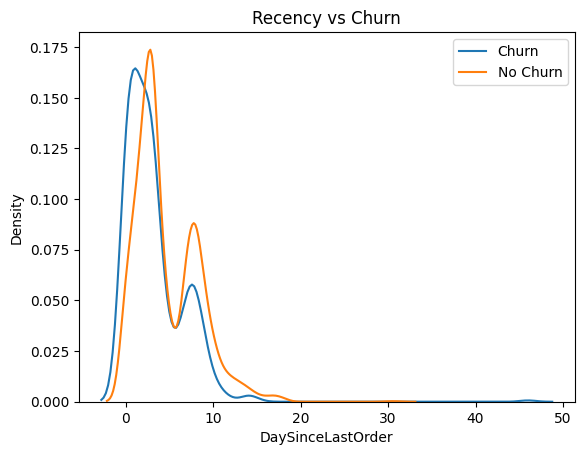

In [48]:
sns.kdeplot(df[df['Churn']==1]['DaySinceLastOrder'], label='Churn')
sns.kdeplot(df[df['Churn']==0]['DaySinceLastOrder'], label='No Churn')
plt.legend()
plt.title("Recency vs Churn")
plt.show()
#recent customers churn more likely
#churns have been more recent

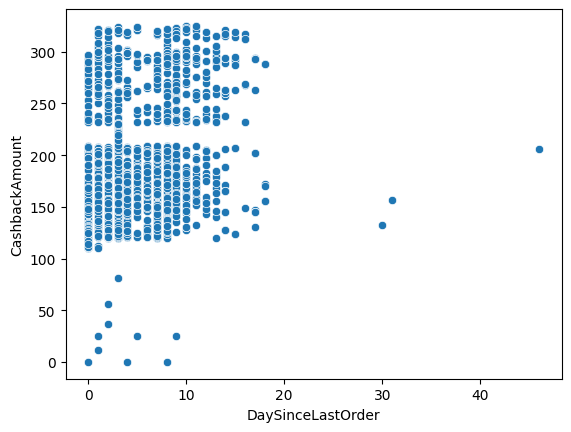

In [49]:
sns.scatterplot(x='DaySinceLastOrder', y='CashbackAmount', data=df)
plt.show()

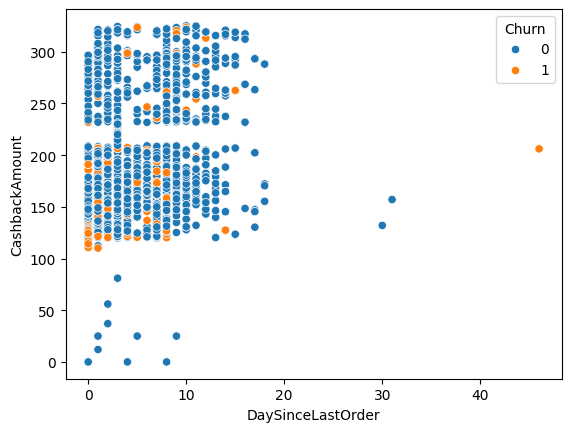

In [50]:
#previous data separated by churn
sns.scatterplot(x='DaySinceLastOrder', y='CashbackAmount', hue='Churn',data=df)
plt.show()

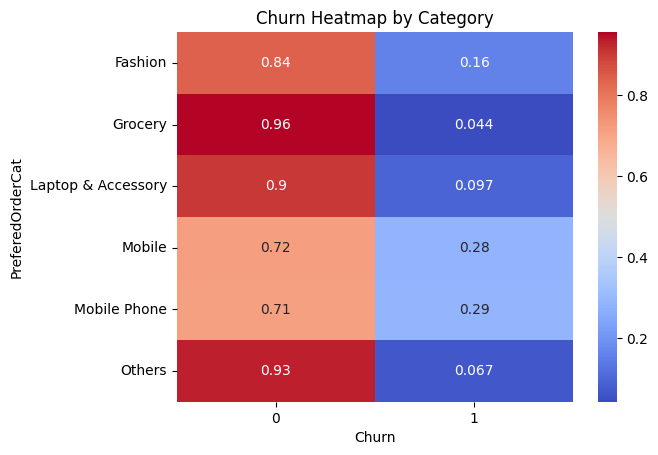

In [51]:
import seaborn as sns
sns.heatmap(
    pd.crosstab(df['PreferedOrderCat'], df['Churn'], normalize='index'),
    annot=True,
    cmap='coolwarm'
)
plt.title("Churn Heatmap by Category")
plt.show()
#categorical heatmap

In [52]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encoding
le=LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Splitting features & target
X=df.drop('Churn', axis=1)
y=df['Churn']

# Scalin
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [53]:
from sklearn.model_selection import train_test_split
# Spliting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [54]:
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)
y_prob_log = logreg.predict_proba(X_test)[:,1]

In [56]:
from sklearn.ensemble import RandomForestClassifier

rfmodel= RandomForestClassifier()
rfmodel.fit(X_train, y_train)

y_pred_rf= rfmodel.predict(X_test)

In [57]:
from sklearn.tree import DecisionTreeClassifier

dtmodel = DecisionTreeClassifier(random_state=42)
dtmodel.fit(X_train, y_train)
y_pred_dt = dtmodel.predict(X_test)
y_prob_dt = dtmodel.predict_proba(X_test)[:,1]

In [58]:
#model evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_test, y_pred, y_prob, model_name):
    print(f"\n o {model_name} Performance:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# Evaluate both models
evaluate_model(y_test, y_pred_log, y_prob_log, "Logistic Regression")
evaluate_model(y_test, y_pred_dt, y_prob_dt, "Decision Tree")
print(f"\n o Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("Confusion Matrix: \n",confusion_matrix(y_test, y_pred_rf))


 o Logistic Regression Performance:
Accuracy: 0.8833967046894804
Precision: 0.7605633802816901
Recall: 0.4186046511627907
F1 Score: 0.54
ROC-AUC Score: 0.8578106647874089

 o Decision Tree Performance:
Accuracy: 0.9062103929024081
Precision: 0.697841726618705
Recall: 0.751937984496124
F1 Score: 0.7238805970149254
ROC-AUC Score: 0.8441508104298803

 o Random Forest Performance:
Accuracy: 0.9493029150823827
Precision: 0.856
Recall: 0.8294573643410853
F1 Score: 0.84251968503937
Confusion Matrix: 
 [[642  18]
 [ 22 107]]


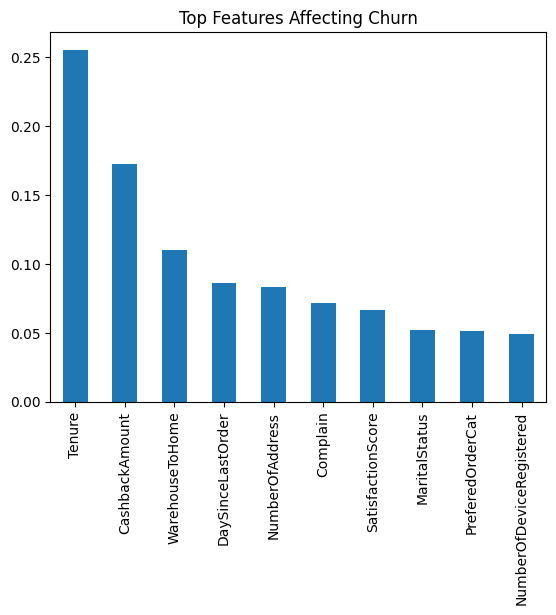

In [65]:
importance = rfmodel.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)
feat_imp.head(10).plot(kind='bar')
plt.title("Top Features Affecting Churn")
plt.show()

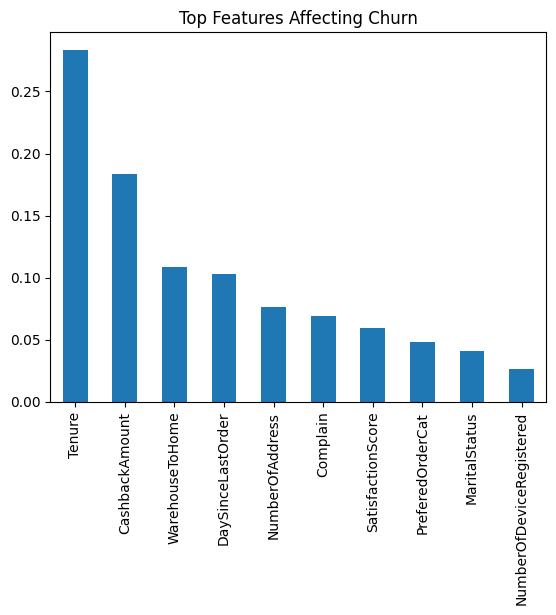

In [66]:
importance = dtmodel.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)
feat_imp.head(10).plot(kind='bar')
plt.title("Top Features Affecting Churn")
plt.show()

In [67]:
def predict_churn(input_data, model, scaler):
    input_scaled=scaler.transform([input_data])
    prediction=model.predict(input_scaled)[0]
    probability=model.predict_proba(input_scaled)[0][1]

    if prediction == 1:
        return f"Churn (Probability: {probability:.2f})"
    else:
        return f"No Churn (Probability: {probability:.2f})"

def main():
    #checking the working of the function
    sample_customer = X.loc[0]
    result=predict_churn(sample_customer, rfmodel, scaler)
    print("\nPrediction Result:", result)
    
    sample_customer = X.loc[82]
    result=predict_churn(sample_customer, rfmodel, scaler)
    print("\nPrediction Result:", result)
if __name__ == "__main__":
    main()


Prediction Result: No Churn (Probability: 0.02)

Prediction Result: Churn (Probability: 0.95)


D:\python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
D:\python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [68]:
#manual checking
sample = X.iloc[82]
actual = y.iloc[82]

pred = rfmodel.predict([sample])[0]

print("Predicted:", pred)
print("Actual:", actual)

Predicted: 1
Actual: 1


In [69]:
import pickle

# Saving models
pickle.dump(logreg, open("logistic_model.pkl", "wb"))
pickle.dump(dtmodel, open("decision_tree_model.pkl", "wb"))

# Saving scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))